# Model building and evaluation

In [34]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/processed/diabetes_food_clean.csv")

In [8]:
df.head()

,CountyID,FoodAccessScore,Urban,SeniorsRate,GroupQuarters,PovertyRatePerc,BlackRate,AsianRate,NHOPIRate,AIANRate,HispanicRate,DiabetesRate,Pop2010,State,County
0,1001,1.410529,0.534460,0.119954,0.008341,0.151376,0.176706,0.008686,0.000586,0.004251,0.024005,0.115555,54571,Alabama,Autauga County
1,1003,0.947357,0.453976,0.167712,0.012653,0.109479,0.093847,0.007396,0.000488,0.006672,0.043848,0.110982,182265,Alabama,Baldwin County
2,1005,1.328587,0.241760,0.142368,0.116296,0.293545,0.468915,0.003897,0.001056,0.004152,0.050515,0.177066,27457,Alabama,Barbour County
3,1007,0.000000,0.000000,0.126816,0.097054,0.138335,0.220249,0.000960,0.000567,0.002793,0.017718,0.131044,22915,Alabama,Bibb County
4,1009,0.245979,0.122989,0.147221,0.008522,0.146238,0.013276,0.002041,0.000663,0.005356,0.080702,0.123109,57322,Alabama,Blount County


In [39]:
# X and y after feature selection (county-level, population-weighted)
X = df[['FoodAccessScore', 'Urban', 'SeniorsRate', 'GroupQuarters', 'PovertyRatePerc',
        'BlackRate', 'AsianRate', 'NHOPIRate', 'AIANRate', 'HispanicRate', 'State']]
y = df['DiabetesRate']

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('state', OneHotEncoder(drop='first', handle_unknown='ignore'), ['State'])
    ],
    remainder='passthrough'
)

model = make_pipeline(
    preprocessor,
    LinearRegression()
)

kf = KFold(n_splits = 5, shuffle = True, random_state = 22)

scores = cross_val_score(
    model,
    X,
    y,
    cv = kf,
    scoring ='r2'
)
print('Our K fold R^2 values are:', scores)
print('Our model R^2 on average is:', round(scores.mean(), 4))

Our K fold R^2 values are: [0.89607253 0.89100575 0.88870929 0.88969183 0.90588389]
Our model R^2 on average is: 0.8943


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# Model interpretation

In [31]:
model = smf.ols(
    'DiabetesRate ~ State + FoodAccessScore + Urban + SeniorsRate + GroupQuarters + PovertyRatePerc +'
    'BlackRate + AsianRate + NHOPIRate + AIANRate + HispanicRate',
    data = df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DiabetesRate   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     474.2
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:18:07   Log-Likelihood:                 10585.
No. Observations:                3121   AIC:                        -2.105e+04
Df Residuals:                    3061   BIC:                        -2.069e+04
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

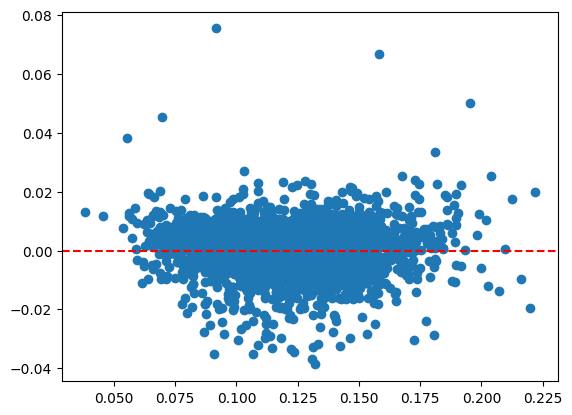

In [36]:
residuals = model.resid
fitted = model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')